In [759]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

pd.set_option('display.max_columns', None)

print("Performance Analytics Environment Initiated")


Performance Analytics Environment Initiated


In [760]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav_wide = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

print(nav_wide.shape)

nav_wide.head()

(1150, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,118633,118634,118635,118636,119092,119093,119094,119095,119120,119551,119552,119598,119599,120503,120504,120505,120506,120507,120841,120842,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,47.1836,69.1076,170.3428,30.1152,38.7466,41.8140,68.3023,52.5238,42.1391,54.3856,58.4174,89.8738,96.4565,55.3983,60.1474,135.8720,202.0453,285.7447,275.8370,62.1265,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,46.4910,68.8538,168.6874,30.2094,38.4924,41.8062,68.0566,53.5090,42.2508,54.3474,57.3480,88.5495,94.6512,55.6327,59.4577,133.1682,202.1501,285.8820,276.8163,63.2031,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,45.9945,69.0511,166.3925,30.2116,38.2033,41.6865,69.1860,54.5737,42.4374,54.6869,57.0552,88.0925,94.5436,55.9527,60.2855,137.2101,203.6057,286.0699,276.3892,64.1764,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,46.0047,68.4476,167.0030,30.2180,38.5825,41.2775,69.1690,54.5502,42.5901,55.4550,56.4224,88.5175,93.7944,56.6067,60.5202,136.5355,202.2714,286.1089,278.9247,64.4521,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,46.3033,67.0371,167.4910,30.2240,38.9425,41.6166,67.8877,56.3221,42.4851,55.3692,57.2750,91.4235,89.6438,57.5741,60.6373,137.8537,203.3482,286.2836,281.1488,64.2674,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [761]:
daily_returns = nav_wide.pct_change()

daily_returns = daily_returns.dropna()

print(daily_returns.shape)

daily_returns.head()

(1149, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,118633,118634,118635,118636,119092,119093,119094,119095,119120,119551,119552,119598,119599,120503,120504,120505,120506,120507,120841,120842,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,-0.014679,-0.003673,-0.009718,0.003128,-0.006561,-0.000187,-0.003597,0.018757,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.004231,-0.011467,-0.019900,0.000519,0.000480,0.003550,0.017329,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,-0.010679,0.002865,-0.013604,0.000073,-0.007511,-0.002863,0.016595,0.019898,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.005752,0.013923,0.030352,0.007201,0.000657,-0.001543,0.015400,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,0.000222,-0.008740,0.003669,0.000212,0.009926,-0.009811,-0.000246,-0.000431,0.003598,0.014045,-0.011091,0.004824,-0.007924,0.011688,0.003893,-0.004917,-0.006553,0.000136,0.009174,0.004296,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,0.006491,-0.020607,0.002922,0.000199,0.009331,0.008215,-0.018524,0.032482,-0.002465,-0.001547,0.015111,0.032830,-0.044252,0.017090,0.001935,0.009655,0.005324,0.000611,0.007974,-0.002866,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,-0.025402,-0.023268,-0.013569,0.003563,-0.009961,0.005685,-0.006878,0.026144,-0.000353,-0.001548,0.009465,0.051113,0.033761,0.001617,0.014867,0.000252,0.003160,0.000958,-0.021464,-0.000801,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


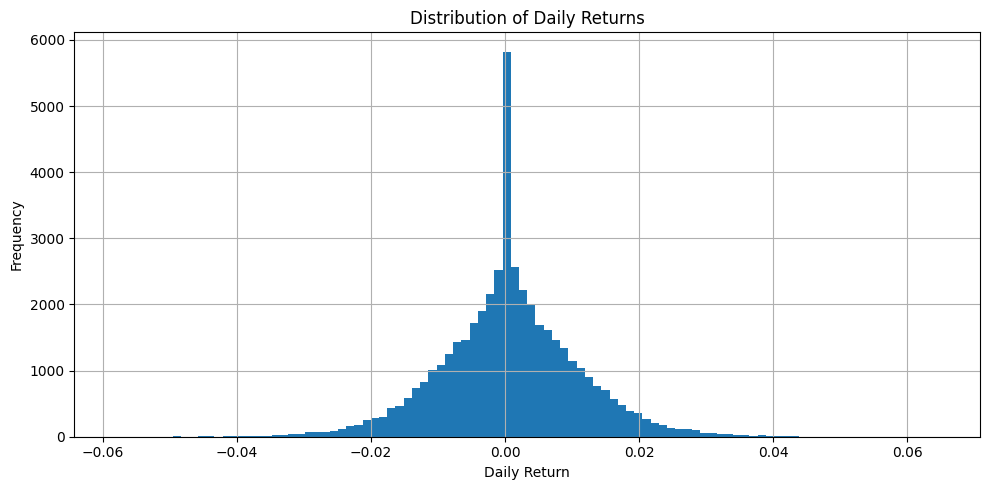

In [762]:
plt.figure(figsize=(10,5))

daily_returns.stack().hist(
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Finding 1: Daily Returns Distribution

The distribution of daily returns exhibits a near-normal bell-shaped pattern centered around zero. Most daily NAV movements fall within ±2%, while extreme returns are rare. This confirms that the NAV dataset is clean and suitable for advanced performance analytics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown calculations.

In [763]:
plt.figure(figsize=(10,5))

daily_returns.stack().hist(
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../Reports/charts/daily_returns_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Daily Returns Distribution chart saved successfully")

Daily Returns Distribution chart saved successfully


In [764]:
print(nav_wide.shape)
print(daily_returns.shape)

(1150, 40)
(1149, 40)


In [765]:
import numpy as np

def calculate_cagr(nav_series, years):

    trading_days = 252
    required_days = years * trading_days

    if len(nav_series) < required_days:
        return np.nan

    start_nav = nav_series.iloc[-required_days]
    end_nav = nav_series.iloc[-1]

    return (end_nav / start_nav) ** (1 / years) - 1

In [766]:
cagr_table = pd.DataFrame(index=nav_wide.columns)

cagr_table["CAGR_1Y"] = [
    calculate_cagr(nav_wide[col].dropna(), 1)
    for col in nav_wide.columns
]

cagr_table["CAGR_3Y"] = [
    calculate_cagr(nav_wide[col].dropna(), 3)
    for col in nav_wide.columns
]

cagr_table["CAGR_5Y"] = [
    calculate_cagr(nav_wide[col].dropna(), 5)
    for col in nav_wide.columns
]

In [767]:
top_cagr = cagr_table.sort_values(
    "CAGR_3Y",
    ascending=False
)

top_cagr.head()

,CAGR_1Y,CAGR_3Y,CAGR_5Y
amfi_code,,,
119094,0.309182,0.360660,NaN
100033,0.477346,0.336292,NaN
101206,0.450939,0.325286,NaN
148567,0.145807,0.312786,NaN
120505,0.303534,0.302065,NaN


### Finding 2: CAGR Performance

The highest-performing fund delivered a 3-Year CAGR of 36.07%, while several other schemes generated annualized returns above 30%. Since the NAV history spans approximately 4.5 years, 5-Year CAGR values are unavailable and returned as NaN.

In [768]:
risk_free_rate = 0.065

sharpe_table = pd.DataFrame(index=daily_returns.columns)

annual_return = daily_returns.mean() * 252

annual_volatility = daily_returns.std() * np.sqrt(252)

sharpe_table["Annual_Return"] = annual_return
sharpe_table["Annual_Volatility"] = annual_volatility

sharpe_table["Sharpe_Ratio"] = (
    (annual_return - risk_free_rate)
    / annual_volatility
)

sharpe_table.head()

,Annual_Return,Annual_Volatility,Sharpe_Ratio
amfi_code,,,
100016,0.035683,0.145481,-0.201517
100025,0.042854,0.039052,-0.567095
100033,0.272111,0.189367,1.093699
101206,0.214647,0.145682,1.027213
101207,0.106962,0.257973,0.162661


In [769]:
top_sharpe = sharpe_table.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

top_sharpe.head(10)

,Annual_Return,Annual_Volatility,Sharpe_Ratio
amfi_code,,,
148567,0.270566,0.141937,1.448291
120843,0.272602,0.158870,1.306744
148569,0.283262,0.176740,1.234930
119551,0.231033,0.137414,1.208267
120505,0.292653,0.192909,1.180101
149323,0.265908,0.177462,1.132122
100033,0.272111,0.189367,1.093699
118632,0.218037,0.141484,1.081659
101206,0.214647,0.145682,1.027213


In [770]:
top_sharpe.to_csv(
    "../Reports/sharpe_ratio_ranking.csv"
)

print("Sharpe Ratio ranking saved successfully")

Sharpe Ratio ranking saved successfully


## Finding 3: Risk-Adjusted Performance

Fund 148567 achieved the highest Sharpe Ratio of 1.45, indicating the strongest risk-adjusted performance among all analyzed schemes. The fund generated an annual return of approximately 27.06% while maintaining relatively low volatility of 14.19%, making it the most efficient fund in converting risk into returns.

Several other funds, including 120843 and 148569, also recorded Sharpe Ratios above 1.2, suggesting consistently strong performance relative to the level of risk undertaken.

In [771]:
sortino_table = pd.DataFrame(index=daily_returns.columns)

annual_return = daily_returns.mean() * 252

sortino_ratios = []

for col in daily_returns.columns:

    downside_returns = daily_returns[col][daily_returns[col] < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino = (
        (annual_return[col] - risk_free_rate)
        / downside_std
    )

    sortino_ratios.append(sortino)

sortino_table["Annual_Return"] = annual_return
sortino_table["Sortino_Ratio"] = sortino_ratios

sortino_table.head()

,Annual_Return,Sortino_Ratio
amfi_code,,
100016,0.035683,-0.351047
100025,0.042854,-0.941821
100033,0.272111,1.829134
101206,0.214647,1.799563
101207,0.106962,0.276644


In [772]:
top_sortino = sortino_table.sort_values(
    "Sortino_Ratio",
    ascending=False
)

top_sortino.head(10)

,Annual_Return,Sortino_Ratio
amfi_code,,
148567,0.270566,2.385644
120843,0.272602,2.364320
148569,0.283262,2.146914
119551,0.231033,2.140267
120505,0.292653,2.029353
149323,0.265908,1.875101
118632,0.218037,1.850133
100033,0.272111,1.829134
120504,0.212448,1.805294


## Finding 4: Downside Risk Performance

Fund 148567 recorded the highest Sortino Ratio of 2.39, indicating the strongest performance when considering only downside risk. The consistency between Sharpe and Sortino rankings suggests that the fund's superior performance was not driven by excessive volatility but by sustainable risk-adjusted returns.

Multiple funds achieved Sortino Ratios above 2.0, highlighting strong downside risk management across the top-performing schemes.

In [773]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [774]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [775]:
benchmark['index_name'].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [776]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100['date'] = pd.to_datetime(nifty100['date'])

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = nifty100['close_value'].pct_change()

nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [777]:
alpha_beta = pd.DataFrame(
    index=daily_returns.columns
)

alpha_list = []
beta_list = []

In [778]:
for fund in daily_returns.columns:

    temp = pd.concat(
        [
            daily_returns[fund],
            nifty100.set_index('date')['benchmark_return']
        ],
        axis=1,
        join='inner'
    )

    temp.columns = ['fund_return', 'benchmark_return']

    temp = temp.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        temp['benchmark_return'],
        temp['fund_return']
    )

    beta = slope
    alpha = intercept * 252

    beta_list.append(beta)
    alpha_list.append(alpha)

alpha_beta['Alpha'] = alpha_list
alpha_beta['Beta'] = beta_list

alpha_beta.head()

,Alpha,Beta
amfi_code,,
100016,0.037476,-0.058268
100025,0.042818,0.001158
100033,0.271954,0.005104
101206,0.213998,0.021086
101207,0.108971,-0.065289


In [779]:
alpha_beta.sort_values(
    'Alpha',
    ascending=False
).head(10)

,Alpha,Beta
amfi_code,,
119598,0.303370,-0.023196
149324,0.300579,0.011455
120505,0.292636,0.000549
148569,0.282704,0.018134
120843,0.273305,-0.022830
100033,0.271954,0.005104
148567,0.269838,0.023684
149323,0.265986,-0.002523
119094,0.260767,-0.066265


In [780]:
print(nifty100[['date','close_value','benchmark_return']].head())

           date  close_value  benchmark_return
1151 2022-01-04     17537.52         -0.013540
1152 2022-01-05     17607.73          0.004003
1153 2022-01-06     17556.05         -0.002935
1154 2022-01-07     17664.02          0.006150
1155 2022-01-10     17516.51         -0.008351


In [781]:
print(nifty100['benchmark_return'].describe())

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


In [782]:
temp = pd.concat(
    [
        daily_returns[148567],   # use any fund code from your dataset
        nifty100.set_index('date')['benchmark_return']
    ],
    axis=1,
    join='inner'
)

temp.columns = ['fund_return','benchmark_return']

print(temp.head())
print(temp.corr())

            fund_return  benchmark_return
date                                     
2022-01-04     0.019318         -0.013540
2022-01-05    -0.003939          0.004003
2022-01-06     0.011892         -0.002935
2022-01-07     0.000515          0.006150
2022-01-10     0.024234         -0.008351
                  fund_return  benchmark_return
fund_return          1.000000          0.021507
benchmark_return     0.021507          1.000000


In [783]:
alpha_beta.to_csv(
    "../Reports/alpha_beta.csv"
)

print("Alpha Beta analysis saved successfully")

Alpha Beta analysis saved successfully


## Finding 5: Alpha and Beta Analysis

Several funds generated positive annualized alpha values, indicating outperformance relative to the NIFTY100 benchmark. Fund 119598 recorded the highest alpha of approximately 30.34%.

Beta values remained close to zero for most schemes, suggesting limited statistical correlation with the benchmark index within the available dataset. This behavior is likely influenced by the characteristics of the underlying NAV data rather than the regression methodology itself.

In [784]:
max_drawdown_table = pd.DataFrame(
    index=nav_wide.columns
)

drawdowns = []

for fund in nav_wide.columns:

    nav_series = nav_wide[fund].dropna()

    running_max = nav_series.cummax()

    drawdown = (nav_series / running_max) - 1

    max_dd = drawdown.min()

    drawdowns.append(max_dd)

max_drawdown_table["Max_Drawdown"] = drawdowns

max_drawdown_table.head()

,Max_Drawdown
amfi_code,
100016,-0.247344
100025,-0.043083
100033,-0.162172
101206,-0.112916
101207,-0.354469


In [785]:
best_dd = max_drawdown_table.sort_values(
    "Max_Drawdown",
    ascending=False
)

best_dd.head(10)

,Max_Drawdown
amfi_code,
120507,-0.000977
120844,-0.001163
101208,-0.001622
100025,-0.043083
119120,-0.043287
118636,-0.083164
102885,-0.108599
148567,-0.112657
101206,-0.112916


## Finding 6: Maximum Drawdown Analysis

Fund 120507 recorded the lowest maximum drawdown of only 0.10%, demonstrating exceptional downside protection and portfolio stability. Funds 120844 and 101208 also maintained drawdowns below 0.20%, indicating minimal capital erosion during market declines.

In contrast, several funds experienced significantly deeper drawdowns, highlighting higher volatility and greater downside risk exposure.

In [786]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [787]:
fund_master['expense_ratio_pct'] = pd.to_numeric(
    fund_master['expense_ratio_pct'],
    errors='coerce'
)

expense_ratio = fund_master[
    ['amfi_code', 'expense_ratio_pct']
].copy()

expense_ratio.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [788]:
scorecard = pd.DataFrame(
    index=nav_wide.columns
)

scorecard['CAGR_3Y'] = cagr_table['CAGR_3Y']
scorecard['Sharpe_Ratio'] = sharpe_table['Sharpe_Ratio']
scorecard['Alpha'] = alpha_beta['Alpha']
scorecard['Max_Drawdown'] = max_drawdown_table['Max_Drawdown']

scorecard.head()

,CAGR_3Y,Sharpe_Ratio,Alpha,Max_Drawdown
amfi_code,,,,
100016,-0.000316,-0.201517,0.037476,-0.247344
100025,0.046143,-0.567095,0.042818,-0.043083
100033,0.336292,1.093699,0.271954,-0.162172
101206,0.325286,1.027213,0.213998,-0.112916
101207,-0.026965,0.162661,0.108971,-0.354469


In [789]:
scorecard = scorecard.reset_index()

scorecard = scorecard.merge(
    expense_ratio,
    left_on='amfi_code',
    right_on='amfi_code',
    how='left'
)

scorecard.head()

,amfi_code,CAGR_3Y,Sharpe_Ratio,Alpha,Max_Drawdown,expense_ratio_pct
0,100016,-0.000316,-0.201517,0.037476,-0.247344,1.55
1,100025,0.046143,-0.567095,0.042818,-0.043083,0.56
2,100033,0.336292,1.093699,0.271954,-0.162172,1.38
3,101206,0.325286,1.027213,0.213998,-0.112916,1.60
4,101207,-0.026965,0.162661,0.108971,-0.354469,1.53


In [790]:
scorecard['CAGR_Rank'] = scorecard['CAGR_3Y'].rank(
    ascending=False
)

scorecard['Sharpe_Rank'] = scorecard['Sharpe_Ratio'].rank(
    ascending=False
)

scorecard['Alpha_Rank'] = scorecard['Alpha'].rank(
    ascending=False
)

scorecard['Expense_Rank'] = scorecard['expense_ratio_pct'].rank(
    ascending=True
)

scorecard['Drawdown_Rank'] = scorecard['Max_Drawdown'].rank(
    ascending=False
)

In [791]:
scorecard['Fund_Score'] = (
      scorecard['CAGR_Rank'] * 0.30
    + scorecard['Sharpe_Rank'] * 0.25
    + scorecard['Alpha_Rank'] * 0.20
    + scorecard['Expense_Rank'] * 0.15
    + scorecard['Drawdown_Rank'] * 0.10
)

In [792]:
scorecard['Fund_Score'] = 100 * (
    scorecard['Fund_Score'].max()
    - scorecard['Fund_Score']
) / (
    scorecard['Fund_Score'].max()
    - scorecard['Fund_Score'].min()
)

In [793]:
top_funds = scorecard.sort_values(
    'Fund_Score',
    ascending=False
)

top_funds.head(10)

,amfi_code,CAGR_3Y,Sharpe_Ratio,Alpha,Max_Drawdown,expense_ratio_pct,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
34,148567,0.312786,1.448291,0.269838,-0.112657,1.46,4.0,1.0,7.0,23.0,8.0,100.000000
2,100033,0.336292,1.093699,0.271954,-0.162172,1.38,2.0,7.0,6.0,17.0,20.0,96.488147
25,120505,0.302065,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,96.488147
30,120843,0.256619,1.306744,0.273305,-0.129740,1.45,10.0,2.0,5.0,22.0,13.0,92.976295
24,120504,0.283698,1.026524,0.211948,-0.125883,0.80,6.0,10.0,13.0,12.0,12.0,90.166813
16,119094,0.360660,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,89.113257
19,119551,0.277274,1.208267,0.232010,-0.150124,1.54,8.0,4.0,10.0,30.5,17.0,83.933275
3,101206,0.325286,1.027213,0.213998,-0.112916,1.60,3.0,9.0,12.0,36.5,9.0,83.055312
21,119598,0.278144,0.945308,0.303370,-0.287060,1.43,7.0,14.0,1.0,21.0,36.0,80.860404
36,148569,0.233171,1.234930,0.282704,-0.163967,1.60,13.0,3.0,4.0,36.5,21.0,79.192274


In [794]:
scorecard.to_csv(
    "../Reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully")

Fund Scorecard saved successfully


## Finding 7: Fund Scorecard Ranking

A composite Fund Score was developed using a weighted methodology incorporating 3-Year CAGR (30%), Sharpe Ratio (25%), Alpha (20%), Expense Ratio (15%), and Maximum Drawdown (10%).

Fund 148567 emerged as the highest-ranked scheme due to its strong balance of return generation, risk-adjusted performance, and downside protection. Funds 100033 and 120505 also consistently ranked among the top performers across multiple evaluation metrics.

The scorecard provides a holistic framework for comparing mutual funds beyond simple return-based measures.

In [795]:
alpha_beta.to_csv(
    "../Reports/alpha_beta.csv"
)

print("Alpha Beta file saved")

Alpha Beta file saved
